# Animal Habitat Classification — MC Dropout Uncertainty

Applies **Monte Carlo Dropout** to the trained MobileNetV3-Small checkpoint.

Dropout is kept **active at inference time** to obtain T stochastic forward passes per image.  
The variance across passes is used as an estimate of **model (epistemic) uncertainty**.

Key sections
- Load the trained model and test data
- Enable MC Dropout (selectively re-activate dropout layers)
- Sweep T = 1 → 21 passes and compare accuracy to standard inference
- Uncertainty analysis: correct vs misclassified samples
- Per-sample visualisation: most/least uncertain images
- Convergence & ranking stability across T

Saved artefacts
- `models/mc_dropout_results.csv` — per-sample uncertainty scores for each T
- `models/mc_dropout_summary.json` — accuracy & mean variance table

## 0 · Setup

In [1]:
import json
from pathlib import Path

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

# Configuration
NUM_CLASSES  = 9 # must match what the model was trained with
DROPOUT = 0.2 # must match training drop_rate
MODEL_NAME = "mobilenetv3_small_100"
CKPT_PATH = Path("models/habitat_mobilenetv3_small_habitat.pth")
SAVE_DIR = Path("models")
T_VALUES = [1, 2, 3, 5, 8, 13, 21] # forward-pass counts to sweep
BATCH_SIZE = 32

SAVE_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"timm : {timm.__version__}")
print(f"torch : {torch.__version__}")

Device : cuda
timm : 1.0.26
torch : 2.11.0+cu126


## 1 · Load Trained Model

We rebuild the same architecture used during training, then load the saved `state_dict`.  
`drop_rate` **must** match the training value so that dropout layers exist in the graph  

In [2]:
def build_model(num_classes: int, dropout: float = DROPOUT) -> nn.Module:
    """Reconstruct MobileNetV3-Small (no pretrained weights needed for inference)."""
    return timm.create_model(
        MODEL_NAME,
        pretrained=False,
        num_classes=num_classes,
        drop_rate=dropout,
    )


model = build_model(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model : {MODEL_NAME}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Params : {total_params:,}")

Model : mobilenetv3_small_100
Checkpoint: models\habitat_mobilenetv3_small_habitat.pth
Params : 1,527,081


## 2 · Data Loading

We load only the **test split** as the rest is not needed (MC Dropout uses inference time so training and val are not needed)

In [4]:
from data_loading_augmentation import make_loaders

config = timm.data.resolve_model_data_config(model)
test_transform = timm.data.create_transform(**config, is_training=False)
_, _, test_loader = make_loaders()

test_ds = test_loader.dataset


class_names = test_ds.classes
print(f"Test samples : {len(test_ds):,}")
print(f"Classes ({len(class_names)}) : {class_names}")

Copying files: 6186 files [00:16, 368.71 files/s]

Test samples : 1,243
Classes (9) : ['dense', 'dense_leafless', 'dense_snow', 'open', 'open_leafless', 'open_snow', 'sparse', 'sparse_leafless', 'sparse_snow']


## 3 · MC Dropout Helpers

In [15]:
def enable_mc_dropout(model: nn.Module) -> nn.Module:
    """
    For MobileNetV3: set full train() mode (activates functional dropout),
    then re-freeze all BatchNorm layers to keep running stats stable.
    """
    model.train()
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            module.eval()
    return model


def mc_dropout_predict(model: nn.Module, loader: DataLoader, T: int, device: torch.device):
    """
    Run T stochastic forward passes with dropout enabled.

    Parameters:
    model : nn.Module
    loader : DataLoader (test loader)
    T : number of stochastic samples
    device : torch.device

    Returns:
    mean_probs : Tensor (N, C)  (averaged softmax over T passes)
    all_probs : Tensor (T, N, C) (raw per-pass softmax outputs)
    """
    enable_mc_dropout(model)
    pass_probs = []
    for _ in tqdm(range(T), desc=f"MC passes (T={T})", leave=False):
        batch_probs = []
        with torch.no_grad():
            for images, _ in loader:
                probs = F.softmax(model(images.to(device)), dim=1)
                batch_probs.append(probs.cpu())
        pass_probs.append(torch.cat(batch_probs))

    all_probs = torch.stack(pass_probs) # (T, N, C)
    mean_probs = all_probs.mean(dim=0) # (N, C)
    return mean_probs, all_probs


# Verification of which layers are active
dropout_layers = [
    (n, type(m).__name__, getattr(m, "p", getattr(m, "drop_prob", None)))
    for n, m in model.named_modules()
    if "Drop" in type(m).__name__
]
# MobileNetV3 uses functional dropout — no named Drop* modules exist.
# We verify BatchNorm layers are frozen instead.
bn_layers = [(n, type(m).__name__) for n, m in model.named_modules()
             if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d))]
print(f"Found {len(bn_layers)} BatchNorm layer(s), these will be frozen during MC Dropout")
print(f"Dropout is applied functionally inside the forward pass (drop_rate={DROPOUT})")

Found 34 BatchNorm layer(s) — these will be frozen during MC Dropout
Dropout is applied functionally inside the forward pass (drop_rate=0.2)


## 4 · Baseline: Standard Inference (Dropout Off)

In [16]:
model.eval()
all_preds_std, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        probs = F.softmax(model(images.to(device)), dim=1)
        all_preds_std.append(probs.cpu())
        all_labels.append(labels)

all_preds_std = torch.cat(all_preds_std)
all_labels = torch.cat(all_labels)

std_acc = accuracy_score(all_labels, all_preds_std.argmax(1))
print(f"Standard inference accuracy : {std_acc:.2%}")

Standard inference accuracy : 92.92%


## 5 · MC Dropout

In [17]:
mc_results = {}

for T in T_VALUES:
    mean_probs, all_probs = mc_dropout_predict(model, test_loader, T, device)
    preds = mean_probs.argmax(dim=1)
    acc = accuracy_score(all_labels, preds)

    # Per-sample uncertainty: mean variance across classes, normalised
    pred_variance = all_probs.var(dim=0).mean(dim=1) # (N,)
    vmax = pred_variance.max()
    if vmax > 0:
        pred_variance = pred_variance / vmax

    mc_results[T] = dict(
        acc=acc,
        mean_probs=mean_probs,
        preds=preds,
        pred_variance=pred_variance,
    )
    print(f"T={T:>3d}  acc={acc:.2%}  mean_norm_var={pred_variance.mean():.4f}")

print(f"\nBaseline (dropout off) : {std_acc:.2%}")

MC passes (T=1):   0%|          | 0/1 [00:00<?, ?it/s]

T=  1  acc=91.95%  mean_norm_var=nan


C:\Users\Maria\AppData\Local\Temp\ipykernel_12244\3063734056.py:9: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  pred_variance = all_probs.var(dim=0).mean(dim=1) # (N,)


MC passes (T=2):   0%|          | 0/2 [00:00<?, ?it/s]

T=  2  acc=92.12%  mean_norm_var=0.0093


...

T=  8  acc=92.76%  mean_norm_var=0.0191


MC passes (T=13):   0%|          | 0/13 [00:00<?, ?it/s]

T= 13  acc=92.60%  mean_norm_var=0.0164


MC passes (T=21):   0%|          | 0/21 [00:00<?, ?it/s]

T= 21  acc=92.92%  mean_norm_var=0.0176

Baseline (dropout off) : 92.92%


## 6 · Results: Accuracy vs Number of Passes

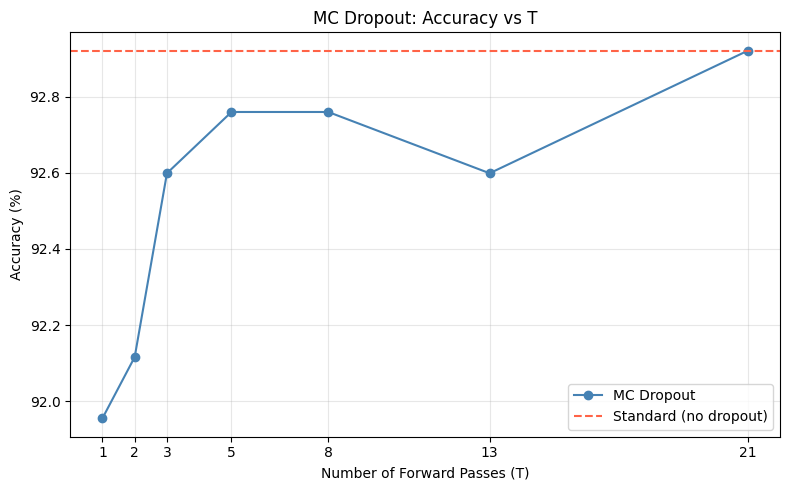

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

accs = [mc_results[T]["acc"] * 100 for T in T_VALUES]
ax.plot(T_VALUES, accs, "o-", color="steelblue", label="MC Dropout")
ax.axhline(std_acc * 100, color="tomato", linestyle="--", label="Standard (no dropout)")

ax.set_xlabel("Number of Forward Passes (T)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("MC Dropout: Accuracy vs T")
ax.set_xticks(T_VALUES)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 · Uncertainty Analysis: Correct vs Misclassified

Misclassified samples should have **higher variance** across passes than correct ones.  
We verify this using the largest T.

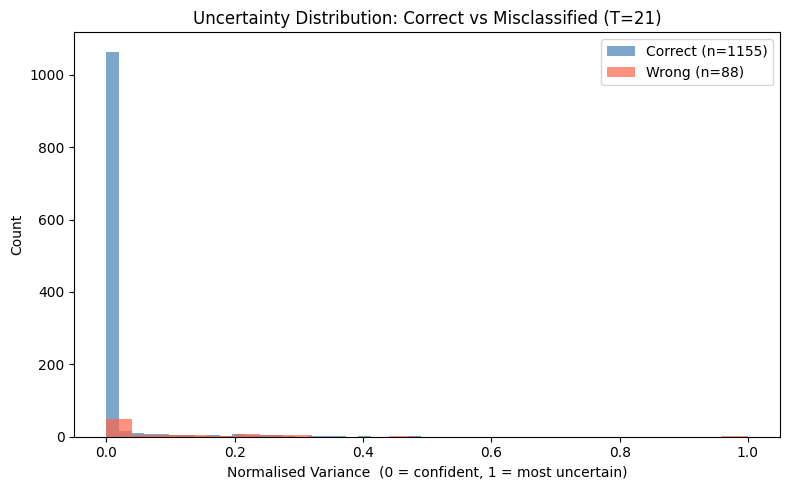

Mean norm. variance — Correct : 0.0116
Mean norm. variance — Wrong : 0.0965


In [19]:
T_best = max(T_VALUES)
res = mc_results[T_best]
correct_mask = res["preds"] == all_labels

correct_vals = res["pred_variance"][correct_mask].numpy()
wrong_vals = res["pred_variance"][~correct_mask].numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correct_vals, bins=25, alpha=0.7,
        label=f"Correct (n={correct_mask.sum()})", color="steelblue")
if len(wrong_vals) > 0:
    ax.hist(wrong_vals, bins=25, alpha=0.7,
            label=f"Wrong (n={(~correct_mask).sum()})", color="tomato")
ax.set_xlabel("Normalised Variance  (0 = confident, 1 = most uncertain)")
ax.set_ylabel("Count")
ax.set_title(f"Uncertainty Distribution: Correct vs Misclassified (T={T_best})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean norm. variance — Correct : {correct_vals.mean():.4f}")
print(f"Mean norm. variance — Wrong : {wrong_vals.mean():.4f}")

## 8 · Per-Sample Visualisation: Most & Least Uncertain

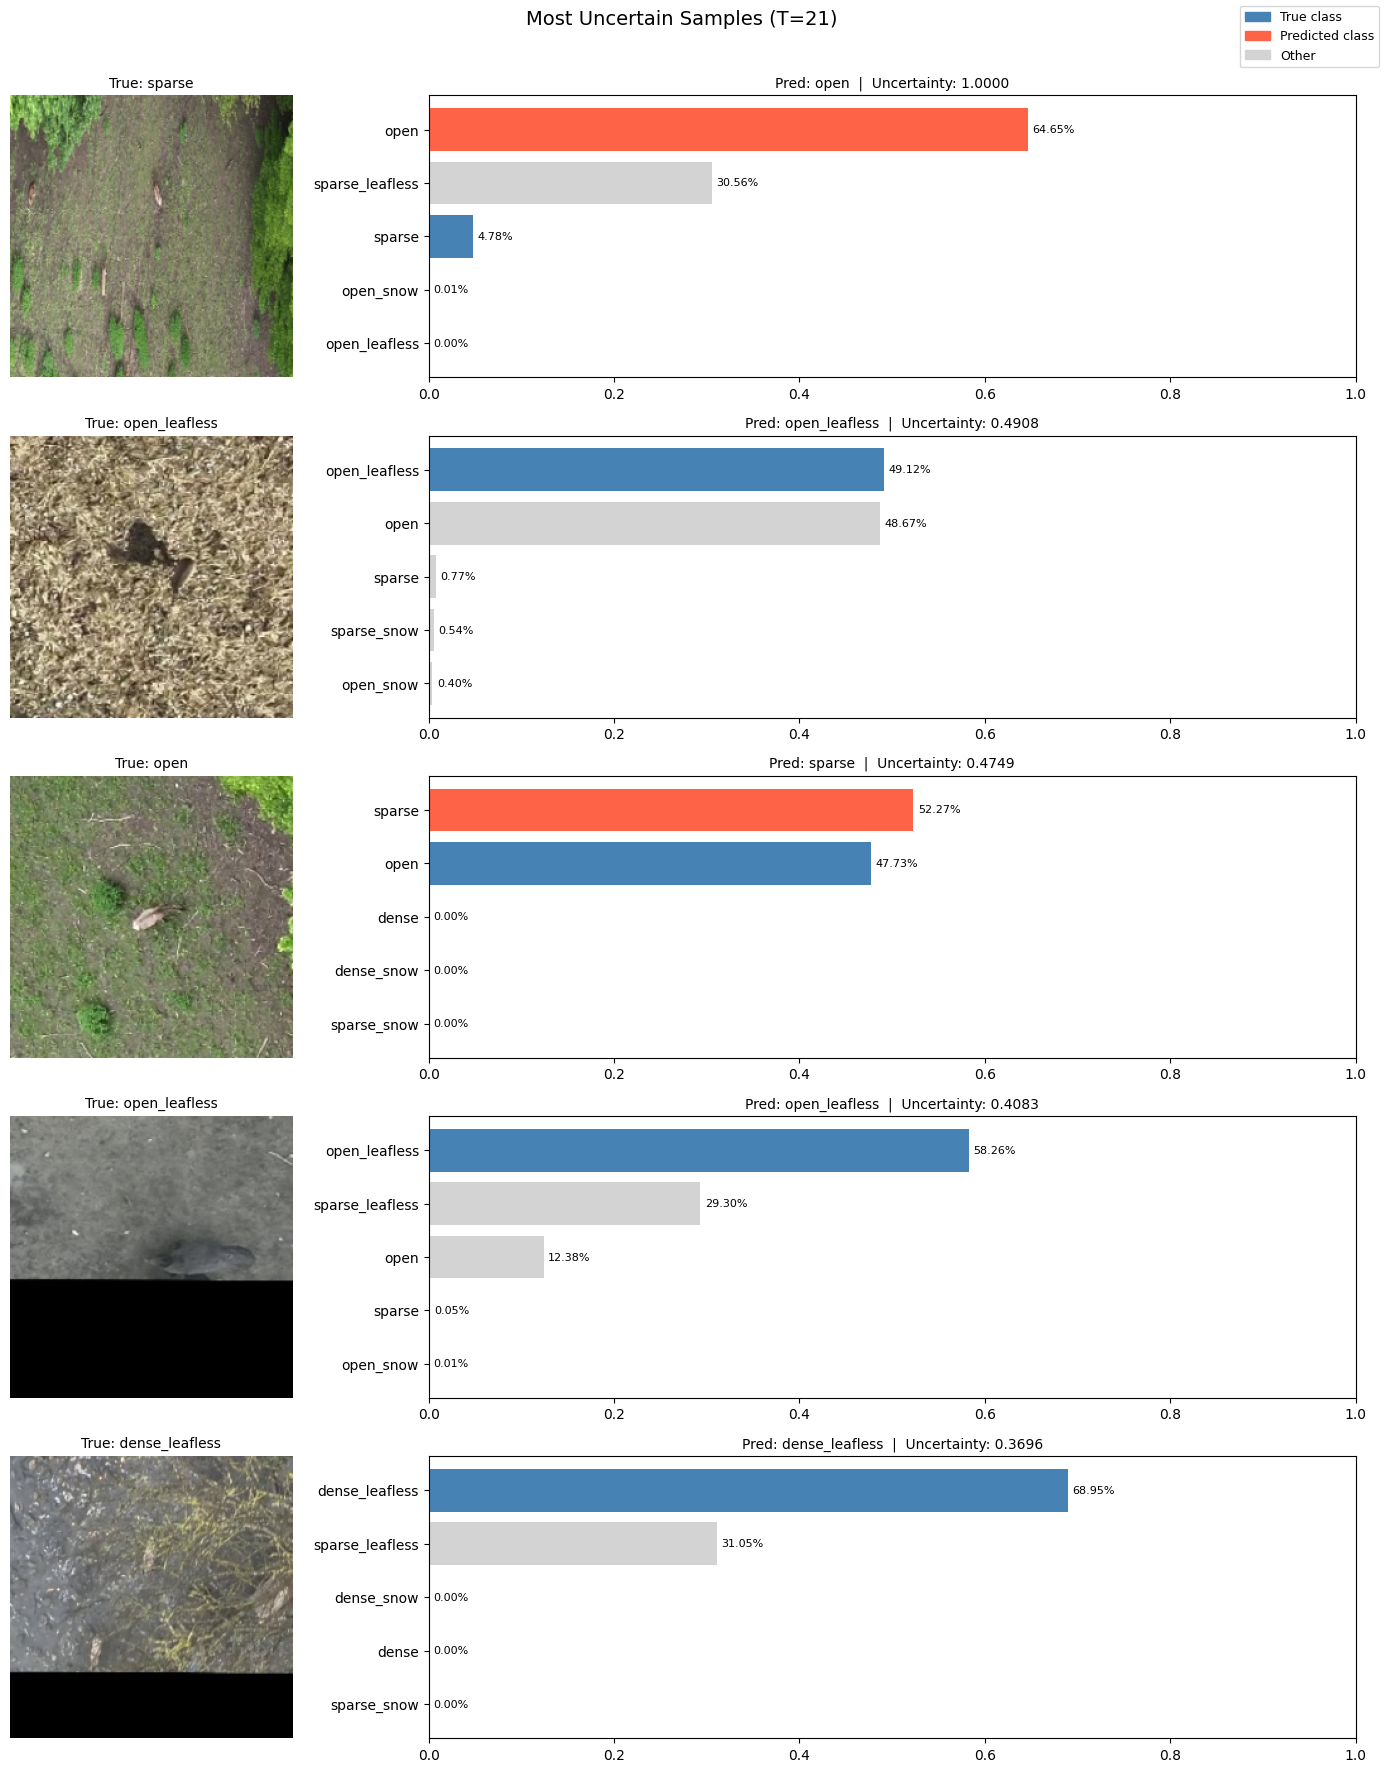

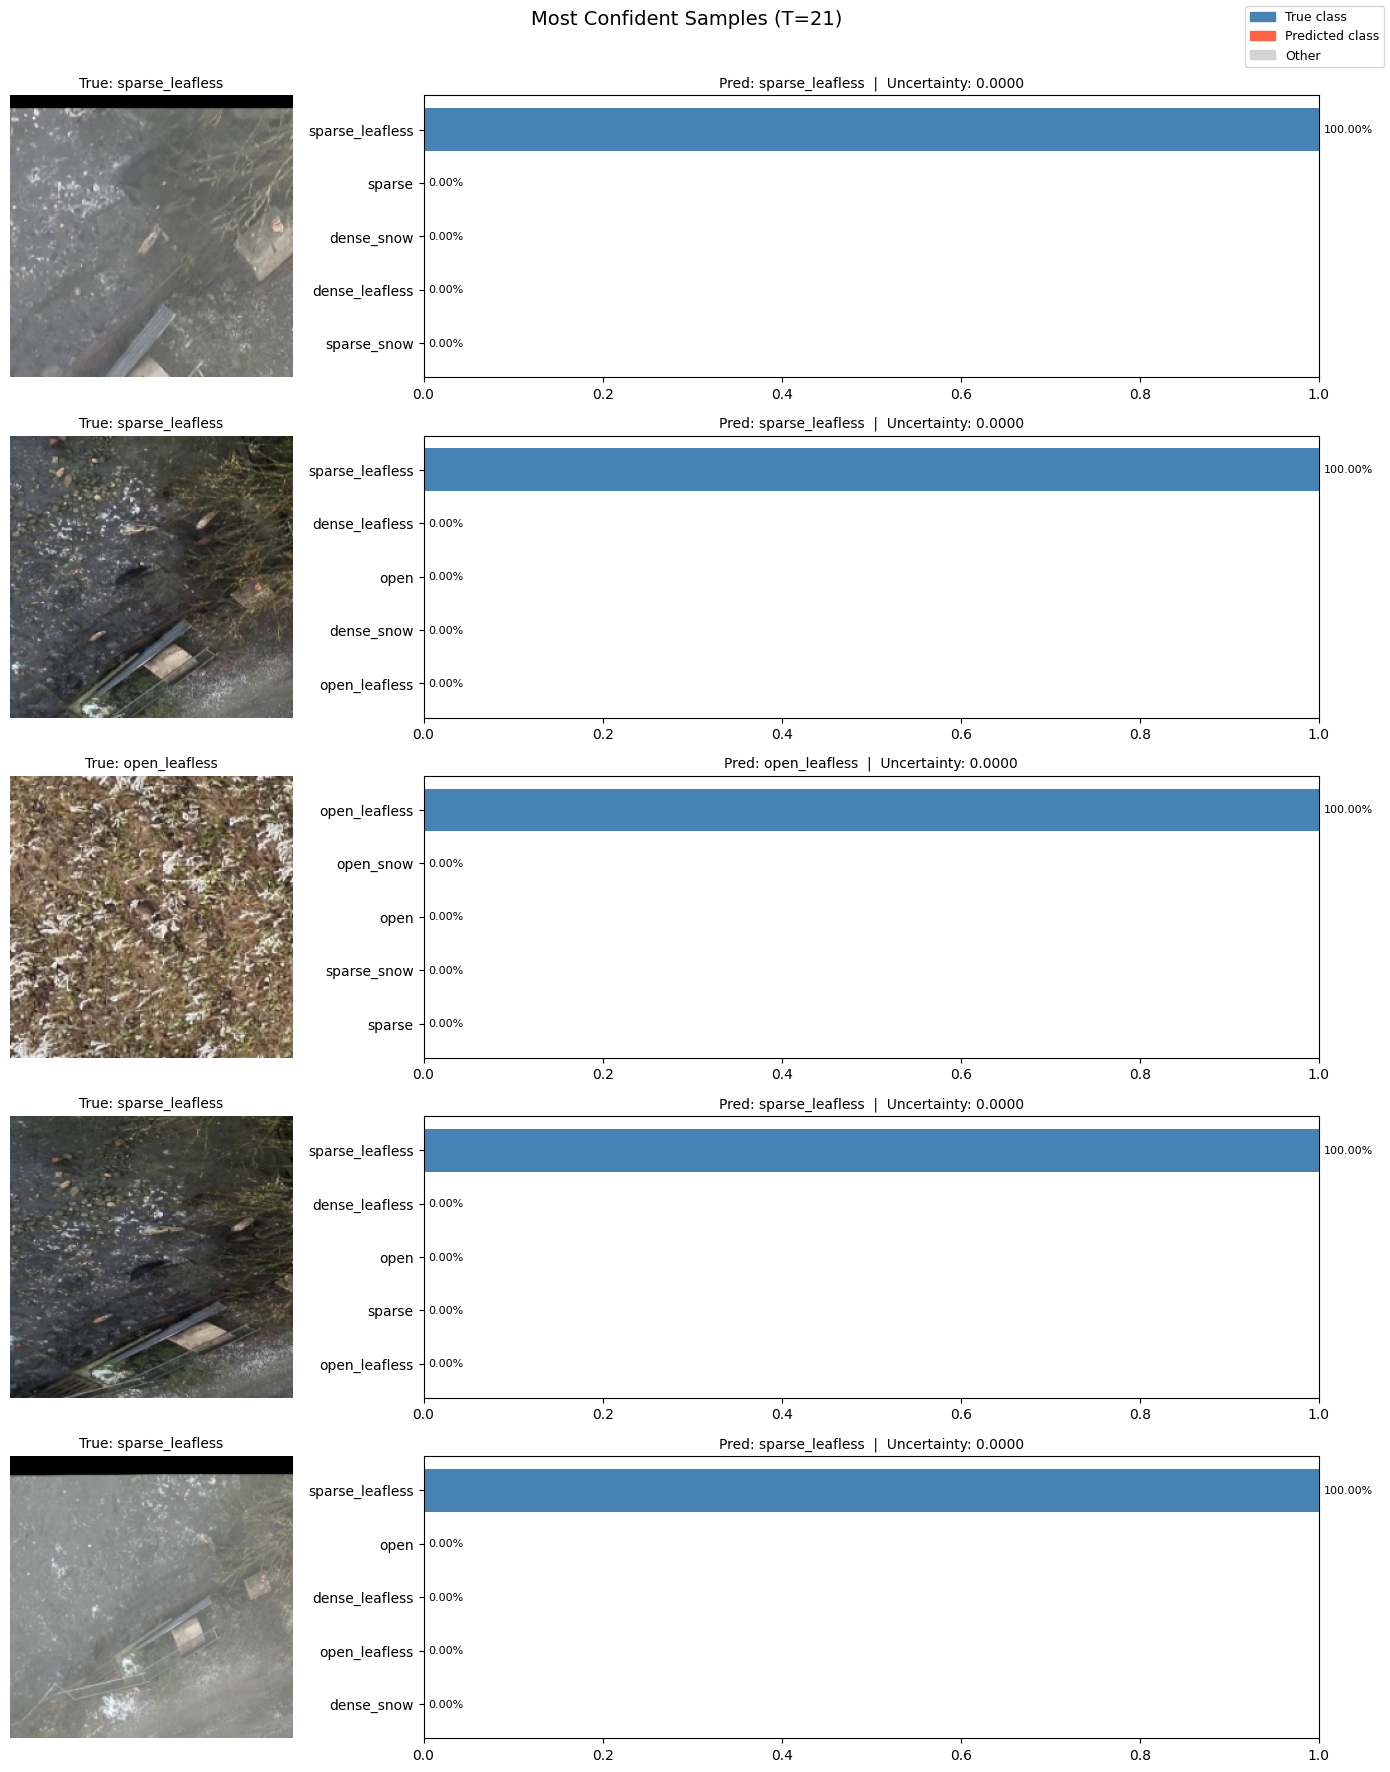

In [20]:
def denorm_image(img_tensor):
    """Convert a normalised CHW tensor to a displayable HWC float32 array in [0, 1]."""
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img.astype(np.float32)


# Collect raw images for display (without shuffling)
all_images = torch.cat([imgs for imgs, _ in test_loader])

variance = res["pred_variance"]
most_uncertain = variance.argsort(descending=True)[:5]
most_confident = variance.argsort()[:5]


def plot_mc_samples(indices, title: str):
    from matplotlib.patches import Patch

    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n),
                             gridspec_kw={"width_ratios": [1, 3]})
    fig.suptitle(title, fontsize=14, y=1.01)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, idx in enumerate(indices):
        true_label = all_labels[idx].item()
        pred_label = res["preds"][idx].item()
        mean_p = res["mean_probs"][idx]
        var_score = variance[idx].item()

        top5_idx = mean_p.argsort(descending=True)[:5]
        top5_names = [class_names[i] for i in top5_idx]
        top5_probs = mean_p[top5_idx].numpy()

        colors = []
        for i in top5_idx:
            if i == true_label and i == pred_label:
                colors.append("steelblue")
            elif i == pred_label:
                colors.append("tomato")
            elif i == true_label:
                colors.append("steelblue")
            else:
                colors.append("lightgray")

        # Image
        axes[row, 0].imshow(denorm_image(all_images[idx]))
        axes[row, 0].set_title(f"True: {class_names[true_label]}", fontsize=10)
        axes[row, 0].axis("off")

        # Probability bar chart
        bars = axes[row, 1].barh(top5_names[::-1], top5_probs[::-1], color=colors[::-1])
        for bar, val in zip(bars, top5_probs[::-1]):
            axes[row, 1].text(bar.get_width() + 0.005,
                              bar.get_y() + bar.get_height() / 2,
                              f"{val:.2%}", va="center", fontsize=8)
        axes[row, 1].set_xlim(0, 1)
        axes[row, 1].set_title(
            f"Pred: {class_names[pred_label]}  |  Uncertainty: {var_score:.4f}",
            fontsize=10)

    legend_elements = [
        Patch(color="steelblue", label="True class"),
        Patch(color="tomato", label="Predicted class"),
        Patch(color="lightgray", label="Other"),
    ]
    fig.legend(handles=legend_elements, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


plot_mc_samples(most_uncertain, f"Most Uncertain Samples (T={T_best})")
plot_mc_samples(most_confident, f"Most Confident Samples (T={T_best})")

## 9 · Uncertainty Convergence Across T
 
plot mean ± std of normalised variance for each T.

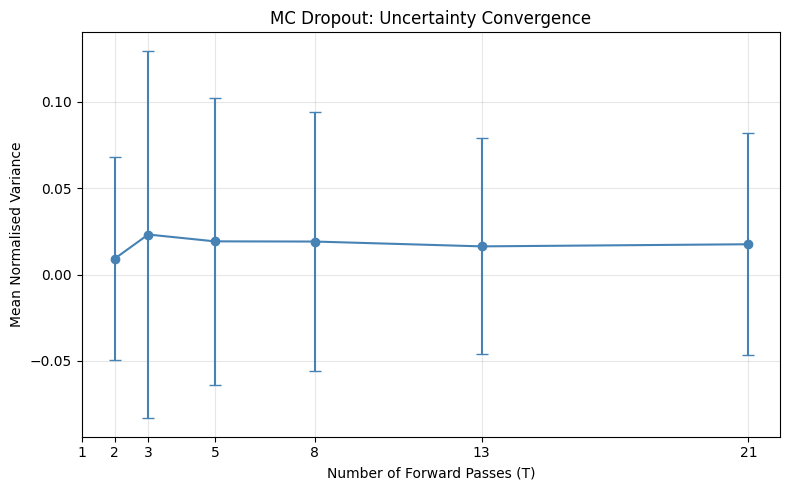

In [21]:
mean_variances = [mc_results[T]["pred_variance"].mean().item() for T in T_VALUES]
std_variances = [mc_results[T]["pred_variance"].std().item()  for T in T_VALUES]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(T_VALUES, mean_variances, yerr=std_variances,
            marker="o", capsize=4, color="steelblue")
ax.set_xlabel("Number of Forward Passes (T)")
ax.set_ylabel("Mean Normalised Variance")
ax.set_title("MC Dropout: Uncertainty Convergence")
ax.set_xticks(T_VALUES)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10 · Ranking Stability Across T

In [22]:
K = 5

rows_uncertain, rows_confident = [], []
for T in T_VALUES:
    var = mc_results[T]["pred_variance"]
    rows_uncertain.append([T] + var.argsort(descending=True)[:K].tolist())
    rows_confident.append([T] + var.argsort()[:K].tolist())

cols = ["T"] + [f"Rank {i+1}" for i in range(K)]
df_uncertain = pd.DataFrame(rows_uncertain, columns=cols).set_index("T")
df_confident = pd.DataFrame(rows_confident, columns=cols).set_index("T")

print("=== Top-5 Most Uncertain Samples (by sample index) ===")
print(df_uncertain.to_string())
print("\n=== Top-5 Most Confident Samples (by sample index) ===")
print(df_confident.to_string())

final_uncertain = set(df_uncertain.loc[T_VALUES[-1]])
final_confident = set(df_confident.loc[T_VALUES[-1]])

print(f"\n=== Ranking Overlap with T={T_VALUES[-1]} (Jaccard) ===")
print(f"{'T':>4s}  {'Uncertain':>10s}  {'Confident':>10s}")
for T in T_VALUES:
    u = set(df_uncertain.loc[T]); c = set(df_confident.loc[T])
    ju = len(u & final_uncertain) / len(u | final_uncertain)
    jc = len(c & final_confident) / len(c | final_confident)
    print(f"{T:4d}  {ju:10.2%}  {jc:10.2%}")

=== Top-5 Most Uncertain Samples (by sample index) ===
    Rank 1  Rank 2  Rank 3  Rank 4  Rank 5
T                                         
1        0       1       2       3       4
2      462     835     588     100     834
3      399     493     122      40     120
5      834     835      84      16     669
8      835    1165     100     493     341
13     835     305     493     183     100
21     835     568     183     490     100

=== Top-5 Most Confident Samples (by sample index) ===
    Rank 1  Rank 2  Rank 3  Rank 4  Rank 5
T                                         
1        0       1       2       3       4
2     1043    1047     633     702     632
3     1043    1047     633     711     622
5     1047     633    1043     625    1051
8     1043    1047    1051     633     711
13    1047     633    1043    1051     711
21    1047    1043     633    1042    1051

=== Ranking Overlap with T=21 (Jaccard) ===
   T   Uncertain   Confident
   1       0.00%       0.00%
   2      25

## 11 · Save Results

Export per-sample uncertainty scores (all T values) and a summary table so  
results can be imported into other notebooks or reports without re-running.

In [23]:
# Per-sample CSV
rows = []
for i in range(len(all_labels)):
    row = {
        "sample_idx"  : i,
        "true_label"  : class_names[all_labels[i].item()],
    }
    for T in T_VALUES:
        res_T = mc_results[T]
        row[f"pred_T{T}"]     = class_names[res_T["preds"][i].item()]
        row[f"variance_T{T}"] = round(res_T["pred_variance"][i].item(), 6)
    rows.append(row)

results_df = pd.DataFrame(rows)
results_csv = SAVE_DIR / "mc_dropout_results.csv"
results_df.to_csv(results_csv, index=False)
print(f"Per-sample results saved : {results_csv}")

# Summary JSON
summary = {
    "model" : MODEL_NAME,
    "checkpoint": str(CKPT_PATH),
    "num_classes": NUM_CLASSES,
    "dropout" : DROPOUT,
    "std_acc" : round(std_acc, 4),
    "mc_sweep" : [
        {
            "T" : T,
            "acc" : round(mc_results[T]["acc"], 4),
            "mean_variance": round(mc_results[T]["pred_variance"].mean().item(), 6),
        }
        for T in T_VALUES
    ],
}

summary_path = SAVE_DIR / "mc_dropout_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved            : {summary_path}")
print(json.dumps(summary, indent=2))

Per-sample results saved : models\mc_dropout_results.csv
Summary saved            : models\mc_dropout_summary.json
{
  "model": "mobilenetv3_small_100",
  "checkpoint": "models\\habitat_mobilenetv3_small_habitat.pth",
  "num_classes": 9,
  "dropout": 0.2,
  "std_acc": 0.9292,
  "mc_sweep": [
    {
      "T": 1,
      "acc": 0.9195,
      "mean_variance": NaN
    },
    {
      "T": 2,
      "acc": 0.9212,
      "mean_variance": 0.009306
    },
    {
      "T": 3,
      "acc": 0.926,
      "mean_variance": 0.023212
    },
    {
      "T": 5,
      "acc": 0.9276,
      "mean_variance": 0.019258
    },
    {
      "T": 8,
      "acc": 0.9276,
      "mean_variance": 0.019146
    },
    {
      "T": 13,
      "acc": 0.926,
      "mean_variance": 0.01635
    },
    {
      "T": 21,
      "acc": 0.9292,
      "mean_variance": 0.017579
    }
  ]
}


## 12 · Confusion Matrix: Standard vs MC Dropout

Compare the confusion matrices for standard inference (dropout off) and MC Dropout (T=21).  
If they differ, the averaged stochastic passes flipped some borderline predictions.  
Per-class accuracy is shown beneath to highlight which habitats benefit most.

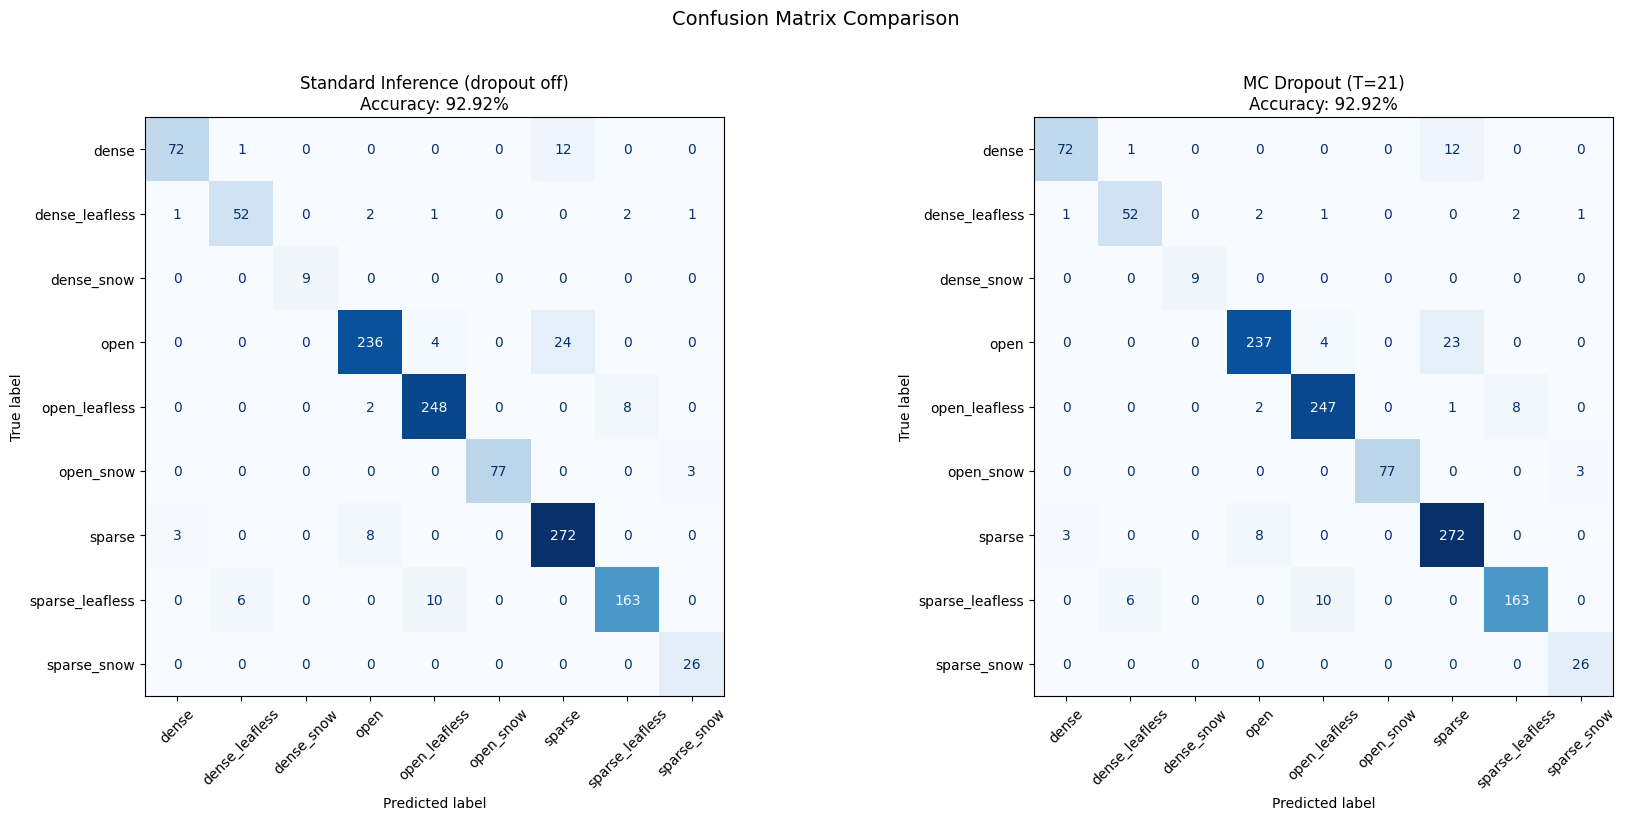

Predictions changed by MC Dropout : 2 / 1243 samples

Per-class accuracy:
          Class   N Std Acc MC Acc (T=21) Δ (MC − Std)
          dense  85  84.71%        84.71%       +0.00%
 dense_leafless  59  88.14%        88.14%       +0.00%
     dense_snow   9 100.00%       100.00%       +0.00%
           open 264  89.39%        89.77%       +0.38%
  open_leafless 258  96.12%        95.74%       -0.39%
      open_snow  80  96.25%        96.25%       +0.00%
         sparse 283  96.11%        96.11%       +0.00%
sparse_leafless 179  91.06%        91.06%       +0.00%
    sparse_snow  26 100.00%       100.00%       +0.00%


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

std_preds = all_preds_std.argmax(1).numpy()
mc_preds  = mc_results[T_best]["preds"].numpy()
labels_np = all_labels.numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, preds, title in zip(
    axes,
    [std_preds, mc_preds],
    ["Standard Inference (dropout off)", f"MC Dropout (T={T_best})"],
):
    cm = confusion_matrix(labels_np, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    acc = (preds == labels_np).mean()
    ax.set_title(f"{title}\nAccuracy: {acc:.2%}", fontsize=12)

plt.suptitle("Confusion Matrix Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#  Highlight any prediction changes
flipped = (std_preds != mc_preds).sum()
print(f"Predictions changed by MC Dropout : {flipped} / {len(std_preds)} samples")

#  Per-class accuracy table
rows = []
for cls_idx, cls_name in enumerate(class_names):
    mask = labels_np == cls_idx
    n    = mask.sum()
    std_correct = (std_preds[mask] == cls_idx).sum()
    mc_correct  = (mc_preds[mask]  == cls_idx).sum()
    rows.append({
        "Class"         : cls_name,
        "N"             : n,
        "Std Acc"       : f"{std_correct/n:.2%}" if n else "—",
        "MC Acc (T=21)" : f"{mc_correct/n:.2%}"  if n else "—",
        "Δ (MC − Std)"  : f"{(mc_correct - std_correct)/n:+.2%}" if n else "—",
    })

df_class = pd.DataFrame(rows)
print("\nPer-class accuracy:")
print(df_class.to_string(index=False))